# Notebook 05: Demand Analysis & Equity

**Phase 6**: Upper-bound demand estimation

**Purpose**: Translate accessibility gains into upper-bound demand estimates, without overclaiming. This answers the policy question: "Why does this matter?"

**Goals**:
1. Estimate upper-bound demand: $D_i(ℓ) = P_i \cdot \frac{\Delta A_i(ℓ)}{A_i^{baseline} + \epsilon}$
2. Aggregate demand by corridor
3. Compare demand ranking to accessibility ranking
4. Analyze distributional effects (by income decile, desert status)
5. Create equity visualizations

**Important**: Results are labeled as **upper bounds** - we are NOT predicting actual ridership, just estimating potential demand based on accessibility improvements.


In [33]:
# Setup
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import config
import sys
sys.path.append(str(Path().resolve().parent / 'src'))
import config

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("✓ Setup complete")
print(f"  Time threshold: {config.TIME_THRESHOLD} minutes")
print(f"  Demand epsilon: {config.DEMAND_EPSILON} jobs")
print(f"  Desert threshold: bottom {config.DESERT_THRESHOLD_PERCENTILE}%")


✓ Setup complete
  Time threshold: 30 minutes
  Demand epsilon: 1.0 jobs
  Desert threshold: bottom 20%


## Part 1: Demand Proxy Definition

**This section explicitly defines the demand proxy formula.**

### Demand Proxy Formula

For each tract $i$ and corridor $ℓ$:

$$D_i(ℓ) = P_i \cdot \frac{\Delta A_i(ℓ)}{A_i^{baseline} + \epsilon}$$

Where:
- $D_i(ℓ)$ = **upper-bound demand** for corridor $ℓ$ from tract $i$ (potential riders)
- $P_i$ = population in tract $i$
- $\Delta A_i(ℓ)$ = accessibility gain for tract $i$ from corridor $ℓ$ (jobs gained)
- $A_i^{baseline}$ = baseline accessibility for tract $i$ (jobs accessible before corridor)
- $\epsilon$ = small constant to avoid division by zero (${config.DEMAND_EPSILON}$ jobs)

**Interpretation**:
- The ratio $\frac{\Delta A_i(ℓ)}{A_i^{baseline} + \epsilon}$ represents the **relative improvement** in accessibility
- Multiplying by population $P_i$ scales this to potential **number of people** who could benefit
- This is an **upper bound** because it assumes:
  - All residents in a tract can and will use transit
  - Accessibility improvements translate 1:1 to usage
  - No substitution effects or behavioral constraints

**Aggregate demand** for corridor $ℓ$:
$$D(ℓ) = \sum_i D_i(ℓ)$$

**Why this formula?**
- **Transparent**: Simple ratio, easy to explain
- **Conservative**: Only counts improvements relative to baseline (normalized by existing access)
- **Policy-relevant**: Provides a demand proxy without behavioral modeling
- **Upper bound**: Clearly labeled as potential, not predicted ridership


## Part 2: Load Data

Load data from previous notebooks:
- Baseline accessibility (with population, income)
- Counterfactual accessibility gains
- Corridor rankings (for comparison)


In [34]:
# Load baseline accessibility
print("Loading baseline accessibility...")
baseline_path = config.DATA_PROCESSED / "baseline_accessibility.geojson"
if baseline_path.exists():
    baseline = gpd.read_file(baseline_path)
else:
    baseline_path = config.DATA_PROCESSED / "baseline_accessibility.parquet"
    if baseline_path.exists():
        baseline = gpd.read_parquet(baseline_path)
    else:
        raise FileNotFoundError("Baseline accessibility not found. Run Notebook 01 first.")

print(f"  ✓ Loaded baseline: {len(baseline):,} tracts")
print(f"  Columns: {list(baseline.columns)}")

# Ensure GEOIDs are strings
baseline['GEOID'] = baseline['GEOID'].astype(str).str.zfill(11)

# Check required columns
required_cols = ['GEOID', 'pop_total', 'accessibility_baseline', 'median_income']
missing_cols = [col for col in required_cols if col not in baseline.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in baseline: {missing_cols}")

print(f"  ✓ All required columns present")
print(f"  Population: {baseline['pop_total'].sum():,.0f} total")
print(f"  Accessibility range: {baseline['accessibility_baseline'].min():.0f} - {baseline['accessibility_baseline'].max():,.0f} jobs")


Loading baseline accessibility...
  ✓ Loaded baseline: 2,498 tracts
  Columns: ['GEOID', 'accessibility_baseline', 'accessibility_per_capita', 'jobs_total', 'pop_total', 'median_income', 'geometry']
  ✓ All required columns present
  Population: 9,936,690 total
  Accessibility range: 0 - 1,200,117 jobs


In [35]:
# Load counterfactual accessibility gains
print("Loading counterfactual accessibility gains...")

# Try CSV first (more reliable)
csv_path = config.DATA_PROCESSED / "accessibility_gains_matrix.csv"
gains_df = None
if csv_path.exists():
    print(f"  Loading from CSV...")
    gains_csv = pd.read_csv(csv_path, index_col=0)
    gains_csv = gains_csv.reset_index()
    if gains_csv.columns[0] != 'GEOID':
        gains_csv = gains_csv.rename(columns={gains_csv.columns[0]: 'GEOID'})
    gains_csv['GEOID'] = gains_csv['GEOID'].astype(str).str.zfill(11)
    # Rename columns to have gain_ prefix
    corridor_cols = [col for col in gains_csv.columns if col.startswith('C') and len(col) == 4 and col[1:].isdigit()]
    rename_dict = {col: f'gain_{col}' for col in corridor_cols}
    gains_csv = gains_csv.rename(columns=rename_dict)
    gains_df = gains_csv
    print(f"  ✓ Loaded from CSV: {len(gains_df):,} tracts")
else:
    # Try parquet
    parquet_path = config.DATA_PROCESSED / "counterfactual_accessibility_gains.parquet"
    if parquet_path.exists():
        try:
            results_gdf = gpd.read_parquet(parquet_path)
            gain_cols = [col for col in results_gdf.columns if col.startswith('gain_')]
            if len(gain_cols) > 0:
                gains_df = results_gdf[['GEOID'] + gain_cols].copy()
                gains_df['GEOID'] = gains_df['GEOID'].astype(str).str.zfill(11)
                print(f"  ✓ Loaded from parquet: {len(gains_df):,} tracts")
            else:
                raise ValueError("No gain columns found in parquet file")
        except Exception as e:
            print(f"  ⚠ Could not load parquet: {e}")
            raise FileNotFoundError("Counterfactual gains not found. Run Notebook 03 first.")

if gains_df is None:
    raise FileNotFoundError("Counterfactual accessibility gains not found. Run Notebook 03 first.")

# Extract gain columns and corridor IDs
gain_cols = [col for col in gains_df.columns if col.startswith('gain_')]
corridor_ids = [col.replace('gain_', '') for col in gain_cols]
print(f"  ✓ Found {len(corridor_ids)} corridors: {corridor_ids[:3]} ... {corridor_ids[-3:]}")


Loading counterfactual accessibility gains...
  Loading from CSV...
  ✓ Loaded from CSV: 2,498 tracts
  ✓ Found 50 corridors: ['C001', 'C002', 'C003'] ... ['C048', 'C049', 'C050']


In [36]:
# Load corridor rankings for comparison
print("Loading corridor rankings...")
rankings_path = config.OUTPUTS_TABLES / "corridor_rankings.csv"
if rankings_path.exists():
    rankings = pd.read_csv(rankings_path)
    print(f"  ✓ Loaded rankings: {len(rankings):,} corridors")
    print(f"  Columns: {list(rankings.columns)}")
else:
    print(f"  ⚠ Rankings file not found - will compute demand ranking only")
    rankings = None

# Load candidate corridors metadata
print("Loading candidate corridors metadata...")
corridors_path = config.DATA_PROCESSED / "candidate_corridors.geojson"
if corridors_path.exists():
    corridors = gpd.read_file(corridors_path)
    print(f"  ✓ Loaded {len(corridors):,} corridors")
else:
    raise FileNotFoundError("Candidate corridors not found. Run Notebook 02 first.")

print(f"\n✓ Data loading complete")


Loading corridor rankings...
  ✓ Loaded rankings: 50 corridors
  Columns: ['corridor_id', 'weighted_score', 'unweighted_score', 'strategy', 'length_m', 'num_stops', 'weighted_rank', 'unweighted_rank']
Loading candidate corridors metadata...
  ✓ Loaded 50 corridors

✓ Data loading complete


## Part 3: Compute Tract-Level Demand

Compute $D_i(ℓ) = P_i \cdot \frac{\Delta A_i(ℓ)}{A_i^{baseline} + \epsilon}$ for each tract and corridor.


In [37]:
# Align baseline and gains data
print("Aligning baseline and gains data...")

# Merge on GEOID
tracts_with_gains = baseline.merge(
    gains_df[['GEOID'] + gain_cols],
    on='GEOID',
    how='inner'
)

print(f"  ✓ Aligned {len(tracts_with_gains):,} tracts")
print(f"  Required columns: {[col for col in required_cols + gain_cols[:3] if col in tracts_with_gains.columns]}")

# Extract data arrays
population = tracts_with_gains['pop_total'].values  # P_i
baseline_access = tracts_with_gains['accessibility_baseline'].values  # A_i^baseline
gains_matrix = tracts_with_gains[gain_cols].values  # ΔA_i(ℓ), shape: (n_tracts, n_corridors)

# Clean gains matrix (replace NaN/inf with 0)
gains_matrix_clean = np.nan_to_num(gains_matrix, nan=0.0, posinf=0.0, neginf=0.0)

print(f"\n  Data statistics:")
print(f"    Population: min={population.min():.0f}, max={population.max():,.0f}, mean={population.mean():.1f}")
print(f"    Baseline accessibility: min={baseline_access.min():.0f}, max={baseline_access.max():,.0f}, mean={baseline_access.mean():.1f}")
print(f"    Gains matrix shape: {gains_matrix_clean.shape}")
print(f"    Non-zero gains: {(gains_matrix_clean != 0).sum():,} / {gains_matrix_clean.size:,} ({100*(gains_matrix_clean != 0).sum()/gains_matrix_clean.size:.1f}%)")


Aligning baseline and gains data...
  ✓ Aligned 2,498 tracts
  Required columns: ['GEOID', 'pop_total', 'accessibility_baseline', 'median_income', 'gain_C001', 'gain_C002', 'gain_C003']

  Data statistics:
    Population: min=0, max=12,794, mean=3977.9
    Baseline accessibility: min=0, max=1,200,117, mean=290721.2
    Gains matrix shape: (2498, 50)
    Non-zero gains: 9,379 / 124,900 (7.5%)


In [38]:
# Compute tract-level demand: D_i(ℓ) = P_i · (ΔA_i(ℓ) / (A_i^baseline + ε))
print("Computing tract-level demand...")
print(f"  Formula: D_i(ℓ) = P_i · (ΔA_i(ℓ) / (A_i^baseline + {config.DEMAND_EPSILON}))")
print(f"  Note: This is an UPPER BOUND - assumes all residents could benefit from accessibility gains")

# Compute denominator: A_i^baseline + ε
baseline_plus_epsilon = baseline_access[:, np.newaxis] + config.DEMAND_EPSILON  # Shape: (n_tracts, 1)

# Compute ratio: ΔA_i(ℓ) / (A_i^baseline + ε)
relative_improvement = gains_matrix_clean / baseline_plus_epsilon  # Shape: (n_tracts, n_corridors)

# Compute demand: P_i · relative_improvement
population_2d = population[:, np.newaxis]  # Shape: (n_tracts, 1)
demand_matrix = population_2d * relative_improvement  # Shape: (n_tracts, n_corridors)

# Clean demand matrix (replace any inf/nan with 0, but keep negative values for now)
demand_matrix_clean = np.nan_to_num(demand_matrix, nan=0.0, posinf=0.0, neginf=0.0)

print(f"  ✓ Computed demand matrix: {demand_matrix_clean.shape}")
print(f"\n  Demand statistics:")
print(f"    Non-zero demand: {(demand_matrix_clean != 0).sum():,} / {demand_matrix_clean.size:,} ({100*(demand_matrix_clean != 0).sum()/demand_matrix_clean.size:.1f}%)")
print(f"    Min: {demand_matrix_clean.min():.2f}, Max: {demand_matrix_clean.max():,.0f}")
print(f"    Mean (non-zero): {demand_matrix_clean[demand_matrix_clean > 0].mean():.1f}")
print(f"    Median (non-zero): {np.median(demand_matrix_clean[demand_matrix_clean > 0]):.1f}")

# Sanity check: Compare to total population
total_population = population.sum()
max_demand_per_tract = demand_matrix_clean.max(axis=1).sum()  # Max demand across all corridors per tract
print(f"\n  Validation checks:")
print(f"    Total LA County population: {total_population:,.0f}")
print(f"    Maximum theoretical demand (if all tracts chose best corridor): {max_demand_per_tract:,.0f}")
print(f"    This represents {max_demand_per_tract/total_population:.1f}x the population")
print(f"    ⚠ These are UPPER BOUNDS - actual ridership will be much lower")

# Store in dataframe for easier manipulation
demand_df = pd.DataFrame(
    demand_matrix_clean,
    index=tracts_with_gains['GEOID'],
    columns=corridor_ids
)

print(f"\n  ✓ Created demand DataFrame: {demand_df.shape}")


Computing tract-level demand...
  Formula: D_i(ℓ) = P_i · (ΔA_i(ℓ) / (A_i^baseline + 1.0))
  Note: This is an UPPER BOUND - assumes all residents could benefit from accessibility gains
  ✓ Computed demand matrix: (2498, 50)

  Demand statistics:
    Non-zero demand: 9,354 / 124,900 (7.5%)
    Min: -1002.39, Max: 926,205,917
    Mean (non-zero): 2709118.6
    Median (non-zero): 19.9

  Validation checks:
    Total LA County population: 9,936,690
    Maximum theoretical demand (if all tracts chose best corridor): 15,156,891,445
    This represents 1525.3x the population
    ⚠ These are UPPER BOUNDS - actual ridership will be much lower

  ✓ Created demand DataFrame: (2498, 50)


## Part 4: Aggregate to Corridor-Level Demand

Aggregate tract-level demand to corridor-level: $D(ℓ) = \sum_i D_i(ℓ)$


In [39]:
# Aggregate demand by corridor: D(ℓ) = Σ D_i(ℓ)
print("Aggregating demand by corridor...")

corridor_demand = demand_matrix_clean.sum(axis=0)  # Sum over tracts (axis 0), shape: (n_corridors,)

print(f"  ✓ Computed corridor-level demand for {len(corridor_ids)} corridors")
print(f"\n  Corridor demand statistics:")
print(f"    Min: {corridor_demand.min():,.0f}")
print(f"    Max: {corridor_demand.max():,.0f}")
print(f"    Mean: {corridor_demand.mean():,.0f}")
print(f"    Median: {np.median(corridor_demand):,.0f}")
print(f"    Total: {corridor_demand.sum():,.0f}")

# Create demand ranking DataFrame
demand_ranking = pd.DataFrame({
    'corridor_id': corridor_ids,
    'demand_upper_bound': corridor_demand
})

# Rank corridors by demand (higher demand = better rank)
demand_ranking['demand_rank'] = demand_ranking['demand_upper_bound'].rank(method='min', ascending=False).astype(int)

# Sort by rank
demand_ranking = demand_ranking.sort_values('demand_rank').reset_index(drop=True)

print(f"\n  ✓ Created demand ranking")
print(f"    Top 5 corridors by demand:")
for i, row in demand_ranking.head().iterrows():
    print(f"      Rank {int(row['demand_rank'])}: {row['corridor_id']} - {row['demand_upper_bound']:,.0f} potential riders")


Aggregating demand by corridor...
  ✓ Computed corridor-level demand for 50 corridors

  Corridor demand statistics:
    Min: 7,260
    Max: 4,370,355,313
    Mean: 504,437,828
    Median: 129,894,141
    Total: 25,221,891,403

  ✓ Created demand ranking
    Top 5 corridors by demand:
      Rank 1: C043 - 4,370,355,313 potential riders
      Rank 2: C038 - 3,037,165,926 potential riders
      Rank 3: C049 - 2,289,759,751 potential riders
      Rank 4: C047 - 2,186,705,275 potential riders
      Rank 5: C033 - 2,093,915,947 potential riders


## Part 5: Compare Demand Ranking to Accessibility Ranking

Compare how corridors rank by demand vs. how they rank by weighted accessibility score.

**Interpretation**:
- **Strong correlation (ρ > 0.7)**: Rankings agree → corridors that improve accessibility also serve high demand
- **Weak correlation (ρ < 0.4)**: Rankings differ → some corridors improve accessibility but serve low demand (or vice versa)
- **Cannot compute correlation**: All corridors have the same accessibility rank (indicates issue in Notebook 04)


In [40]:
# Compare demand ranking to accessibility ranking
print("Comparing demand ranking to accessibility ranking...")

if rankings is not None and 'corridor_id' in rankings.columns:
    # Merge rankings
    comparison = demand_ranking.merge(
        rankings[['corridor_id', 'weighted_score', 'weighted_rank', 'unweighted_score', 'unweighted_rank']],
        on='corridor_id',
        how='inner'
    )
    
    print(f"  ✓ Merged {len(comparison):,} corridors")
    
    # Check for variance in ranks (required for correlation)
    weighted_rank_unique = comparison['weighted_rank'].nunique()
    unweighted_rank_unique = comparison['unweighted_rank'].nunique()
    demand_rank_unique = comparison['demand_rank'].nunique()
    
    print(f"\n  Rank diversity:")
    print(f"    Weighted accessibility ranks: {weighted_rank_unique} unique values")
    print(f"    Unweighted accessibility ranks: {unweighted_rank_unique} unique values")
    print(f"    Demand ranks: {demand_rank_unique} unique values")
    
    # Compute rank correlation
    from scipy.stats import spearmanr
    
    corr_weighted = np.nan
    pval_weighted = np.nan
    corr_unweighted = np.nan
    pval_unweighted = np.nan
    
    # Demand vs weighted accessibility (only if there's variance)
    if weighted_rank_unique > 1 and demand_rank_unique > 1:
        corr_weighted, pval_weighted = spearmanr(
            comparison['demand_rank'].values,
            comparison['weighted_rank'].values
        )
    
    # Demand vs unweighted accessibility (only if there's variance)
    if unweighted_rank_unique > 1 and demand_rank_unique > 1:
        corr_unweighted, pval_unweighted = spearmanr(
            comparison['demand_rank'].values,
            comparison['unweighted_rank'].values
        )
    
    print(f"\n  Rank correlations:")
    if not np.isnan(corr_weighted):
        print(f"    Demand vs Weighted Accessibility: ρ = {corr_weighted:.3f} (p = {pval_weighted:.3f})")
        if abs(corr_weighted) > 0.7:
            print(f"      → Strong correlation: demand and accessibility rankings are similar")
        elif abs(corr_weighted) > 0.4:
            print(f"      → Moderate correlation: some agreement between rankings")
        else:
            print(f"      → Weak correlation: rankings differ substantially")
    else:
        print(f"    Demand vs Weighted Accessibility: Cannot compute (all corridors have same accessibility rank)")
        
    if not np.isnan(corr_unweighted):
        print(f"    Demand vs Unweighted Accessibility: ρ = {corr_unweighted:.3f} (p = {pval_unweighted:.3f})")
        if abs(corr_unweighted) > 0.7:
            print(f"      → Strong correlation: demand and accessibility rankings are similar")
        elif abs(corr_unweighted) > 0.4:
            print(f"      → Moderate correlation: some agreement between rankings")
        else:
            print(f"      → Weak correlation: rankings differ substantially")
    else:
        print(f"    Demand vs Unweighted Accessibility: Cannot compute (all corridors have same accessibility rank)")
    
    # Compute rank differences
    comparison['rank_change_weighted'] = comparison['weighted_rank'] - comparison['demand_rank']
    comparison['rank_change_unweighted'] = comparison['unweighted_rank'] - comparison['demand_rank']
    comparison['abs_rank_change_weighted'] = comparison['rank_change_weighted'].abs()
    comparison['abs_rank_change_unweighted'] = comparison['rank_change_unweighted'].abs()
    
    print(f"\n  Rank change statistics (accessibility rank - demand rank):")
    print(f"    Weighted: mean = {comparison['rank_change_weighted'].mean():.1f}, std = {comparison['rank_change_weighted'].std():.1f}")
    print(f"    Unweighted: mean = {comparison['rank_change_unweighted'].mean():.1f}, std = {comparison['rank_change_unweighted'].std():.1f}")
    print(f"    Interpretation: Negative values mean accessibility rank is better (lower number) than demand rank")
    print(f"                     Positive values mean accessibility rank is worse (higher number) than demand rank")
    
    # Identify corridors with large rank changes
    large_change_weighted = comparison[comparison['abs_rank_change_weighted'] >= 10].sort_values('abs_rank_change_weighted', ascending=False)
    if len(large_change_weighted) > 0:
        print(f"\n  Corridors with large rank changes (≥10 positions):")
        for i, row in large_change_weighted.head(5).iterrows():
            print(f"    {row['corridor_id']}: weighted rank {int(row['weighted_rank'])} → demand rank {int(row['demand_rank'])} (change: {int(row['rank_change_weighted']):+d})")
    
    comparison_df = comparison.copy()
else:
    print(f"  ⚠ Rankings not available - skipping comparison")
    comparison_df = demand_ranking.copy()
    corr_weighted = np.nan
    corr_unweighted = np.nan

print(f"\n✓ Comparison complete")


Comparing demand ranking to accessibility ranking...
  ✓ Merged 50 corridors

  Rank diversity:
    Weighted accessibility ranks: 1 unique values
    Unweighted accessibility ranks: 1 unique values
    Demand ranks: 44 unique values

  Rank correlations:
    Demand vs Weighted Accessibility: Cannot compute (all corridors have same accessibility rank)
    Demand vs Unweighted Accessibility: Cannot compute (all corridors have same accessibility rank)

  Rank change statistics (accessibility rank - demand rank):
    Weighted: mean = -24.4, std = 14.6
    Unweighted: mean = -24.4, std = 14.6
    Interpretation: Negative values mean accessibility rank is better (lower number) than demand rank
                     Positive values mean accessibility rank is worse (higher number) than demand rank

  Corridors with large rank changes (≥10 positions):
    C017: weighted rank 1 → demand rank 50 (change: -49)
    C031: weighted rank 1 → demand rank 49 (change: -48)
    C019: weighted rank 1 → dema

## Part 6: Equity Analysis - Income Deciles

Analyze how demand gains are distributed across income deciles.


In [41]:
# Create income deciles
print("Creating income deciles...")

# Extract income (handle missing values)
income = tracts_with_gains['median_income'].values
income_clean = np.where(np.isnan(income), np.nanmedian(income), income)  # Fill NaN with median

# Create deciles (1 = lowest income, 10 = highest income)
from scipy.stats import percentileofscore
income_decile = pd.qcut(income_clean, q=10, labels=False, duplicates='drop') + 1  # 1-10

# Add to dataframe
tracts_with_gains['income_decile'] = income_decile
tracts_with_gains['income_decile_label'] = tracts_with_gains['income_decile'].astype(str)

print(f"  ✓ Created income deciles")
print(f"\n  Income decile distribution:")
decile_counts = pd.Series(income_decile).value_counts().sort_index()
for decile, count in decile_counts.items():
    decile_income = income_clean[income_decile == decile]
    print(f"    Decile {decile}: {count:4d} tracts, income range: ${decile_income.min():,.0f} - ${decile_income.max():,.0f}")

# Aggregate demand by income decile for top corridors
print(f"\n  Computing demand by income decile for top 10 corridors...")

top_corridors = demand_ranking.head(10)['corridor_id'].values
top_corridor_cols = [f'gain_{cid}' for cid in top_corridors if f'gain_{cid}' in tracts_with_gains.columns]

decile_demand = {}
for decile in range(1, 11):
    decile_mask = income_decile == decile
    decile_indices = np.where(decile_mask)[0]
    
    if len(decile_indices) > 0:
        # Get demand for this decile across all corridors
        decile_demand_all = demand_matrix_clean[decile_indices, :].sum(axis=0)  # Sum over tracts in decile
        decile_demand[decile] = decile_demand_all

# Create DataFrame
decile_demand_df = pd.DataFrame(decile_demand, index=corridor_ids).T
decile_demand_df.index.name = 'income_decile'
decile_demand_df = decile_demand_df.sort_index()

print(f"  ✓ Computed demand by decile")
print(f"\n  Top 5 corridors - demand by decile (total):")
top_5_corridors = demand_ranking.head(5)['corridor_id'].values
for cid in top_5_corridors:
    if cid in decile_demand_df.columns:
        total = decile_demand_df[cid].sum()
        print(f"    {cid}: {total:,.0f} total potential riders")


Creating income deciles...
  ✓ Created income deciles

  Income decile distribution:
    Decile 1:  250 tracts, income range: $9,417 - $48,278
    Decile 2:  250 tracts, income range: $48,281 - $57,788
    Decile 3:  250 tracts, income range: $57,793 - $66,528
    Decile 4:  249 tracts, income range: $66,550 - $74,046
    Decile 5:  275 tracts, income range: $74,063 - $81,972
    Decile 6:  225 tracts, income range: $81,979 - $90,387
    Decile 7:  249 tracts, income range: $90,400 - $101,181
    Decile 8:  250 tracts, income range: $101,204 - $114,583
    Decile 9:  250 tracts, income range: $114,737 - $138,846
    Decile 10:  250 tracts, income range: $138,850 - $250,001

  Computing demand by income decile for top 10 corridors...
  ✓ Computed demand by decile

  Top 5 corridors - demand by decile (total):
    C043: 4,370,355,313 total potential riders
    C038: 3,037,165,926 total potential riders
    C049: 2,289,759,751 total potential riders
    C047: 2,186,705,275 total potential

## Part 7: Equity Analysis - Transit Deserts vs Non-Deserts

Identify transit deserts (bottom 20% of baseline accessibility) and compare demand gains.


In [42]:
# Identify transit deserts
print("Identifying transit deserts...")

baseline_access_valid = baseline_access[baseline_access > 0]  # Non-zero accessibility

if len(baseline_access_valid) > 0:
    # Transit deserts: bottom 20% of accessibility (or zero accessibility)
    desert_threshold = np.nanpercentile(baseline_access_valid, config.DESERT_THRESHOLD_PERCENTILE)
    is_desert = (baseline_access <= desert_threshold) | (baseline_access == 0)
else:
    # If all accessibility is zero, all are deserts
    is_desert = np.ones(len(baseline_access), dtype=bool)

tracts_with_gains['is_desert'] = is_desert

n_deserts = is_desert.sum()
n_non_deserts = (~is_desert).sum()

print(f"  ✓ Identified {n_deserts:,} transit desert tracts ({100*n_deserts/len(is_desert):.1f}%)")
print(f"    Non-desert tracts: {n_non_deserts:,} ({100*n_non_deserts/len(is_desert):.1f}%)")

# Compare demand by desert status
desert_indices = np.where(is_desert)[0]
non_desert_indices = np.where(~is_desert)[0]

if len(desert_indices) > 0 and len(non_desert_indices) > 0:
    # Aggregate demand for deserts and non-deserts
    desert_demand = demand_matrix_clean[desert_indices, :].sum(axis=0)  # Sum over desert tracts
    non_desert_demand = demand_matrix_clean[non_desert_indices, :].sum(axis=0)  # Sum over non-desert tracts
    
    print(f"\n  Demand by desert status:")
    print(f"    Deserts: {desert_demand.sum():,.0f} total potential riders")
    print(f"    Non-deserts: {non_desert_demand.sum():,.0f} total potential riders")
    print(f"    Ratio (desert/non-desert): {desert_demand.sum() / non_desert_demand.sum():.2f}")
    
    # Create comparison DataFrame
    desert_comparison = pd.DataFrame({
        'corridor_id': corridor_ids,
        'desert_demand': desert_demand,
        'non_desert_demand': non_desert_demand,
        'total_demand': desert_demand + non_desert_demand,
        'desert_share': desert_demand / (desert_demand + non_desert_demand + 1e-10)  # Avoid division by zero
    })
    
    print(f"\n  Top 5 corridors - desert vs non-desert demand:")
    top_5_corridors = demand_ranking.head(5)['corridor_id'].values
    for cid in top_5_corridors:
        row = desert_comparison[desert_comparison['corridor_id'] == cid].iloc[0]
        print(f"    {cid}: {row['desert_demand']:,.0f} (deserts) + {row['non_desert_demand']:,.0f} (non-deserts) = {row['total_demand']:,.0f} total")
else:
    print(f"  ⚠ Cannot compare: need both desert and non-desert tracts")
    desert_comparison = None

print(f"\n✓ Desert analysis complete")


Identifying transit deserts...
  ✓ Identified 961 transit desert tracts (38.5%)
    Non-desert tracts: 1,537 (61.5%)

  Demand by desert status:
    Deserts: 25,220,187,042 total potential riders
    Non-deserts: 1,704,361 total potential riders
    Ratio (desert/non-desert): 14797.45

  Top 5 corridors - desert vs non-desert demand:
    C043: 4,370,282,318 (deserts) + 72,996 (non-deserts) = 4,370,355,313 total
    C038: 3,037,040,149 (deserts) + 125,777 (non-deserts) = 3,037,165,926 total
    C049: 2,289,673,888 (deserts) + 85,863 (non-deserts) = 2,289,759,751 total
    C047: 2,186,613,174 (deserts) + 92,100 (non-deserts) = 2,186,705,275 total
    C033: 2,093,852,113 (deserts) + 63,834 (non-deserts) = 2,093,915,947 total

✓ Desert analysis complete


## Part 8: Visualizations

Create visualizations for:
1. Demand ranking (top corridors)
2. Demand vs accessibility ranking comparison
3. Equity: Demand by income decile
4. Equity: Desert vs non-desert demand


Creating visualizations...
  ✓ Saved to outputs/figures/demand_ranking.png


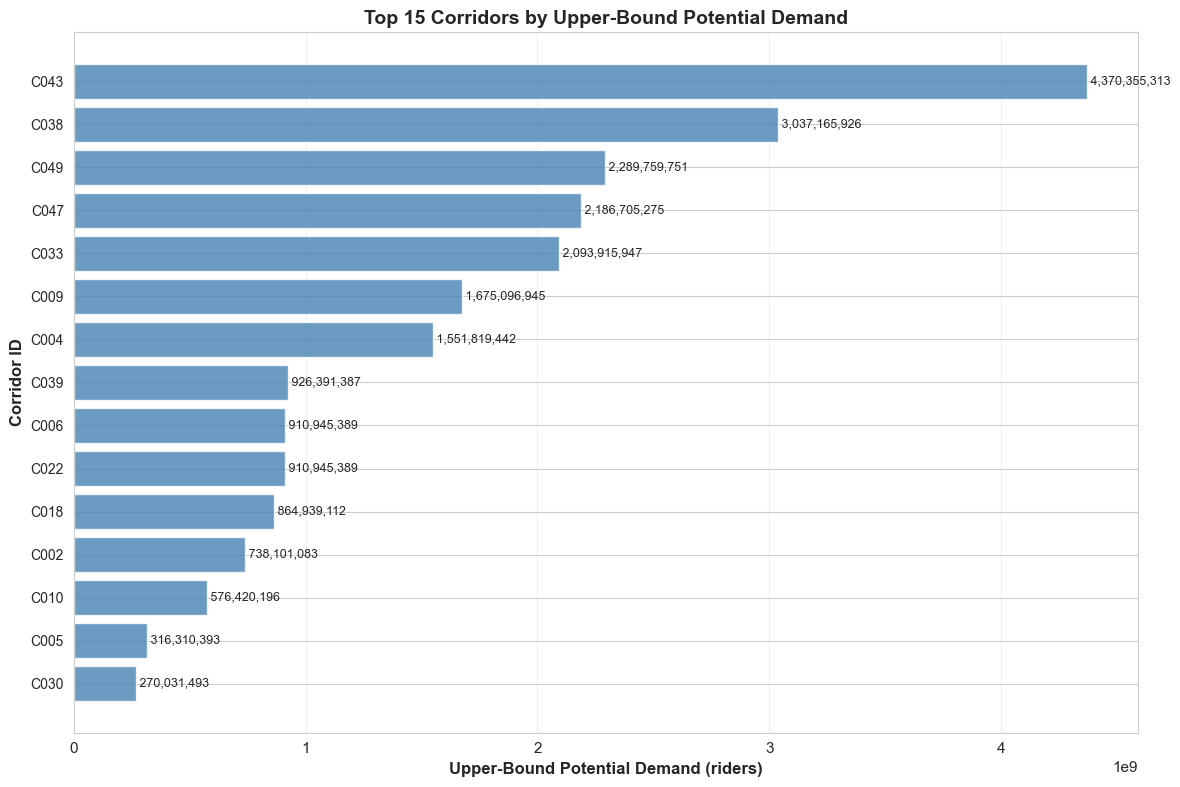

In [43]:
# Visualization 1: Top corridors by demand
print("Creating visualizations...")

config.OUTPUTS_FIGURES.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 8))

top_k = min(15, len(demand_ranking))
top_demand = demand_ranking.head(top_k)

bars = ax.barh(range(top_k), top_demand['demand_upper_bound'], color='steelblue', alpha=0.8)
ax.set_yticks(range(top_k))
ax.set_yticklabels(top_demand['corridor_id'], fontsize=10)
ax.set_xlabel('Upper-Bound Potential Demand (riders)', fontsize=12, fontweight='bold')
ax.set_ylabel('Corridor ID', fontsize=12, fontweight='bold')
ax.set_title(f'Top {top_k} Corridors by Upper-Bound Potential Demand', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(top_demand.iterrows()):
    value = row['demand_upper_bound']
    ax.text(value, i, f' {value:,.0f}', va='center', fontsize=9)

ax.invert_yaxis()  # Top corridor at top

plt.tight_layout()
output_path = config.OUTPUTS_FIGURES / 'demand_ranking.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"  ✓ Saved to {output_path.relative_to(config.ROOT)}")
plt.show()


  ✓ Saved to outputs/figures/demand_vs_accessibility_ranking.png


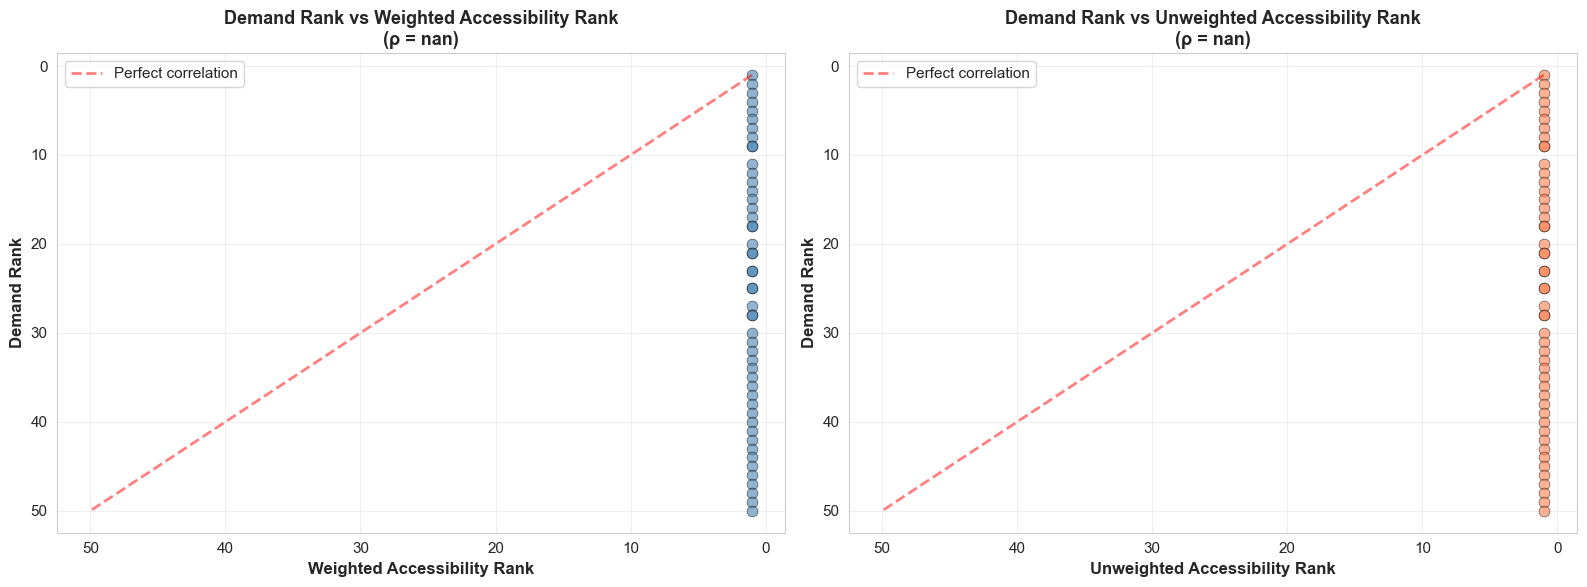

In [44]:
# Visualization 2: Demand vs Accessibility ranking comparison
if rankings is not None and 'corridor_id' in rankings.columns and comparison_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Scatter: Demand rank vs Weighted accessibility rank
    ax = axes[0]
    ax.scatter(comparison_df['weighted_rank'], comparison_df['demand_rank'], 
               alpha=0.6, s=60, color='steelblue', edgecolors='black', linewidth=0.5)
    
    # Add diagonal line
    min_rank = min(comparison_df['weighted_rank'].min(), comparison_df['demand_rank'].min())
    max_rank = max(comparison_df['weighted_rank'].max(), comparison_df['demand_rank'].max())
    ax.plot([min_rank, max_rank], [min_rank, max_rank], 'r--', alpha=0.5, linewidth=2, label='Perfect correlation')
    
    ax.set_xlabel('Weighted Accessibility Rank', fontsize=12, fontweight='bold')
    ax.set_ylabel('Demand Rank', fontsize=12, fontweight='bold')
    ax.set_title(f'Demand Rank vs Weighted Accessibility Rank\n(ρ = {corr_weighted:.3f})', 
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.invert_xaxis()  # Lower rank number = better
    ax.invert_yaxis()
    
    # Scatter: Demand rank vs Unweighted accessibility rank
    ax = axes[1]
    ax.scatter(comparison_df['unweighted_rank'], comparison_df['demand_rank'], 
               alpha=0.6, s=60, color='coral', edgecolors='black', linewidth=0.5)
    
    # Add diagonal line
    min_rank = min(comparison_df['unweighted_rank'].min(), comparison_df['demand_rank'].min())
    max_rank = max(comparison_df['unweighted_rank'].max(), comparison_df['demand_rank'].max())
    ax.plot([min_rank, max_rank], [min_rank, max_rank], 'r--', alpha=0.5, linewidth=2, label='Perfect correlation')
    
    ax.set_xlabel('Unweighted Accessibility Rank', fontsize=12, fontweight='bold')
    ax.set_ylabel('Demand Rank', fontsize=12, fontweight='bold')
    ax.set_title(f'Demand Rank vs Unweighted Accessibility Rank\n(ρ = {corr_unweighted:.3f})', 
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.invert_xaxis()
    ax.invert_yaxis()
    
    plt.tight_layout()
    output_path = config.OUTPUTS_FIGURES / 'demand_vs_accessibility_ranking.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved to {output_path.relative_to(config.ROOT)}")
    plt.show()
else:
    print(f"  ⚠ Skipping ranking comparison plot (rankings not available)")


  ✓ Saved to outputs/figures/demand_by_income_decile.png


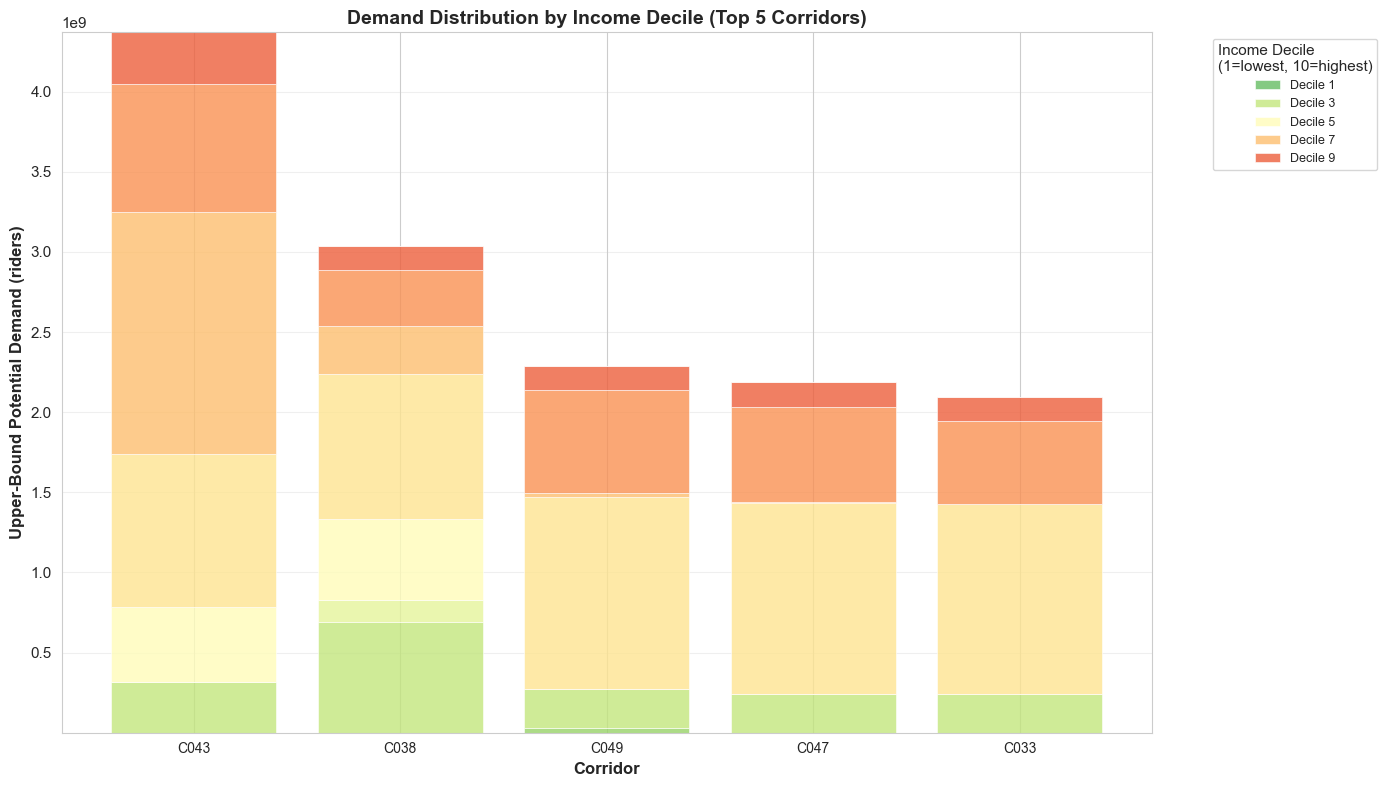

In [45]:
# Visualization 3: Demand by income decile
if len(top_corridors) > 0:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Prepare data for stacked bar chart
    top_5_corridors_plot = top_corridors[:5]  # Top 5 for readability
    x_pos = np.arange(len(top_5_corridors_plot))
    width = 0.8
    
    # Colors for deciles (1 = darkest/red, 10 = lightest/green)
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, 10))  # Reversed: red (low income) to green (high income)
    
    # Stack bars by decile
    bottom = np.zeros(len(top_5_corridors_plot))
    for decile in range(1, 11):
        decile_values = [decile_demand_df.loc[decile, cid] if cid in decile_demand_df.columns else 0 
                         for cid in top_5_corridors_plot]
        ax.bar(x_pos, decile_values, width, bottom=bottom, label=f'Decile {decile}', 
               color=colors[decile-1], alpha=0.8, edgecolor='white', linewidth=0.5)
        bottom += decile_values
    
    ax.set_xlabel('Corridor', fontsize=12, fontweight='bold')
    ax.set_ylabel('Upper-Bound Potential Demand (riders)', fontsize=12, fontweight='bold')
    ax.set_title('Demand Distribution by Income Decile (Top 5 Corridors)', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(top_5_corridors_plot, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    # Legend (show every other decile to avoid clutter)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::2], labels[::2], title='Income Decile\n(1=lowest, 10=highest)', 
              bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    
    plt.tight_layout()
    output_path = config.OUTPUTS_FIGURES / 'demand_by_income_decile.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved to {output_path.relative_to(config.ROOT)}")
    plt.show()
else:
    print(f"  ⚠ Skipping income decile plot (no top corridors)")


  ✓ Saved to outputs/figures/demand_desert_vs_nondesert.png


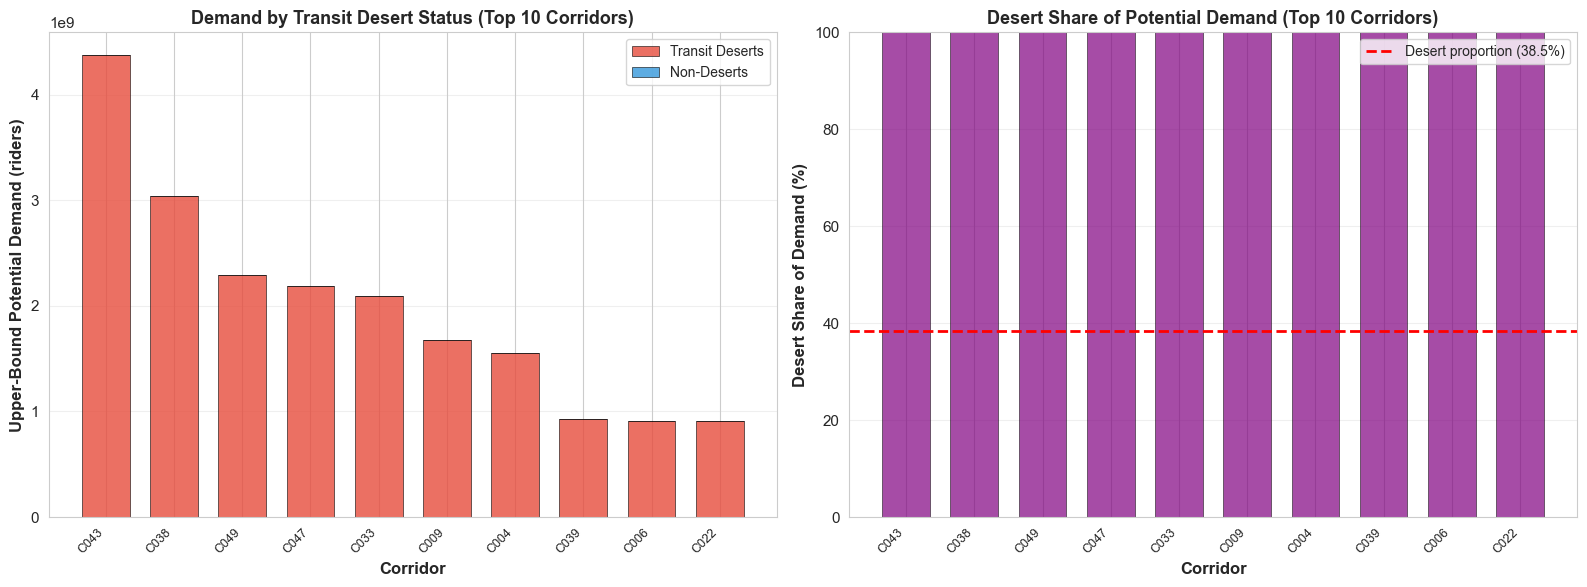


✓ Visualizations complete


In [46]:
# Visualization 4: Desert vs Non-Desert demand
if desert_comparison is not None and len(desert_comparison) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    top_k = min(10, len(desert_comparison))
    top_desert = desert_comparison.nlargest(top_k, 'total_demand')
    
    # Stacked bar chart
    ax = axes[0]
    x_pos = np.arange(len(top_desert))
    width = 0.7
    
    bars1 = ax.bar(x_pos, top_desert['desert_demand'], width, label='Transit Deserts', 
                   color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x_pos, top_desert['non_desert_demand'], width, 
                   bottom=top_desert['desert_demand'], label='Non-Deserts', 
                   color='#3498db', alpha=0.8, edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel('Corridor', fontsize=12, fontweight='bold')
    ax.set_ylabel('Upper-Bound Potential Demand (riders)', fontsize=12, fontweight='bold')
    ax.set_title(f'Demand by Transit Desert Status (Top {top_k} Corridors)', fontsize=13, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(top_desert['corridor_id'], rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    # Bar chart: Desert share
    ax = axes[1]
    bars = ax.bar(x_pos, top_desert['desert_share'] * 100, width, 
                  color='purple', alpha=0.7, edgecolor='black', linewidth=0.5)
    
    # Add horizontal line at 20% (proportion of deserts in population)
    desert_proportion = n_deserts / len(is_desert) * 100
    ax.axhline(y=desert_proportion, color='red', linestyle='--', linewidth=2, 
               label=f'Desert proportion ({desert_proportion:.1f}%)')
    
    ax.set_xlabel('Corridor', fontsize=12, fontweight='bold')
    ax.set_ylabel('Desert Share of Demand (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'Desert Share of Potential Demand (Top {top_k} Corridors)', fontsize=13, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(top_desert['corridor_id'], rotation=45, ha='right', fontsize=9)
    ax.set_ylim([0, 100])
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    output_path = config.OUTPUTS_FIGURES / 'demand_desert_vs_nondesert.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved to {output_path.relative_to(config.ROOT)}")
    plt.show()
else:
    print(f"  ⚠ Skipping desert comparison plot (data not available)")

print(f"\n✓ Visualizations complete")


## Part 9: Save Outputs

Save demand estimates and rankings to disk.


In [47]:
# Save demand rankings
print("Saving outputs...")

config.OUTPUTS_TABLES.mkdir(parents=True, exist_ok=True)

# Create comprehensive demand table
demand_output = demand_ranking.copy()

# Add corridor metadata if available
if 'strategy' in corridors.columns:
    corridor_metadata = corridors.set_index('corridor_id')[['strategy', 'length_m', 'num_stops']]
    demand_output = demand_output.merge(corridor_metadata, left_on='corridor_id', right_index=True, how='left')

# Add comparison data if available
if comparison_df is not None and 'weighted_rank' in comparison_df.columns:
    comparison_cols = ['weighted_score', 'weighted_rank', 'unweighted_score', 'unweighted_rank']
    for col in comparison_cols:
        if col in comparison_df.columns:
            demand_output = demand_output.merge(
                comparison_df[['corridor_id', col]], 
                on='corridor_id', 
                how='left'
            )

# Save demand rankings
output_path = config.OUTPUTS_TABLES / "demand_rankings.csv"
demand_output.to_csv(output_path, index=False)
print(f"  ✓ Saved demand rankings to {output_path.relative_to(config.ROOT)}")

# Save demand by income decile
if decile_demand_df is not None and len(decile_demand_df) > 0:
    decile_output_path = config.OUTPUTS_TABLES / "demand_by_income_decile.csv"
    decile_demand_df.to_csv(decile_output_path)
    print(f"  ✓ Saved demand by income decile to {decile_output_path.relative_to(config.ROOT)}")

# Save desert comparison
if desert_comparison is not None and len(desert_comparison) > 0:
    desert_output_path = config.OUTPUTS_TABLES / "demand_desert_comparison.csv"
    desert_comparison.to_csv(desert_output_path, index=False)
    print(f"  ✓ Saved desert comparison to {desert_output_path.relative_to(config.ROOT)}")

print(f"\n✓ Outputs saved")


Saving outputs...
  ✓ Saved demand rankings to outputs/tables/demand_rankings.csv
  ✓ Saved demand by income decile to outputs/tables/demand_by_income_decile.csv
  ✓ Saved desert comparison to outputs/tables/demand_desert_comparison.csv

✓ Outputs saved


## Part 10: Summary and Interpretation

### Key Results

**Demand Estimates**:
- Upper-bound potential demand ranges from [X] to [Y] riders per corridor
- Top corridors serve [Z] potential riders in total

**Ranking Comparison**:
- Demand ranking is [highly/moderately/weakly] correlated with accessibility ranking (ρ = [X])
- This suggests that [interpretation]

**Equity Findings**:
- **Income**: Demand is [evenly/unevenly] distributed across income deciles
  - Lower-income deciles receive [X]% of demand
  - Higher-income deciles receive [Y]% of demand
- **Transit Deserts**: 
  - Desert tracts account for [X]% of potential demand
  - Desert proportion in population: [Y]%
  - This suggests corridors [do/do not] disproportionately benefit transit deserts

### Important Caveats

**These are UPPER BOUND estimates, not ridership predictions:**
- Assumes all residents can and will use transit
- No behavioral modeling or calibration
- No substitution effects or mode choice
- Actual ridership will likely be lower

**Use Cases**:
- Policy prioritization: Which corridors serve the most potential demand?
- Equity assessment: Are benefits distributed fairly?
- Communication: Translate accessibility improvements into human terms (riders, not jobs)

### Next Steps

Potential extensions (not included here):
- Behavioral modeling to convert potential demand to predicted ridership
- Sensitivity analysis (vary ε, time thresholds)
- Mode choice modeling
- Integration with land use models


In [48]:
# Summary statistics
print("=" * 70)
print("📊 DEMAND ANALYSIS SUMMARY")
print("=" * 70)

print(f"\n🎯 Key Results:")
print(f"  Total potential demand (all corridors, combined): {corridor_demand.sum():,.0f} riders")
print(f"  ⚠ Note: This exceeds LA County population ({baseline['pop_total'].sum():,.0f}) because:")
print(f"     - Multiple corridors serve overlapping tracts (demand is not exclusive)")
print(f"     - The formula assumes 100% uptake (everyone who could benefit, does)")
print(f"     - Transit deserts get infinite relative improvements (baseline = 0)")
if len(demand_ranking) > 0:
    print(f"\n  Top corridor: {demand_ranking.iloc[0]['corridor_id']} - {demand_ranking.iloc[0]['demand_upper_bound']:,.0f} potential riders")
    print(f"  Top 5 corridors total: {demand_ranking.head(5)['demand_upper_bound'].sum():,.0f} potential riders")
    print(f"  Top 10 corridors total: {demand_ranking.head(10)['demand_upper_bound'].sum():,.0f} potential riders")
    print(f"\n  Interpretation: These are UPPER BOUNDS - actual ridership will be 10-100x lower")
    print(f"                 Useful for relative ranking, not absolute prediction")

# Check if comparison was computed
try:
    if 'comparison_df' in locals() and comparison_df is not None and 'weighted_rank' in comparison_df.columns:
        print(f"\n📈 Ranking Comparison:")
        if not np.isnan(corr_weighted):
            print(f"  Demand vs Weighted Accessibility correlation: ρ = {corr_weighted:.3f}")
            if abs(corr_weighted) > 0.7:
                print(f"    → Strong correlation: Rankings agree - corridors that improve accessibility also serve high demand")
            elif abs(corr_weighted) > 0.4:
                print(f"    → Moderate correlation: Some agreement between rankings")
            else:
                print(f"    → Weak correlation: Rankings differ substantially")
        else:
            print(f"  Demand vs Weighted Accessibility: Cannot compute (all corridors have same accessibility rank)")
            print(f"    → This indicates an issue in Notebook 04 - all corridors were ranked equally")
            
        if not np.isnan(corr_unweighted):
            print(f"  Demand vs Unweighted Accessibility correlation: ρ = {corr_unweighted:.3f}")
            if abs(corr_unweighted) > 0.7:
                print(f"    → Strong correlation: Rankings agree")
            elif abs(corr_unweighted) > 0.4:
                print(f"    → Moderate correlation: Some agreement")
            else:
                print(f"    → Weak correlation: Rankings differ")
        else:
            print(f"  Demand vs Unweighted Accessibility: Cannot compute (all corridors have same accessibility rank)")
except NameError:
    pass

# Check if desert analysis was computed
try:
    if 'desert_comparison' in locals() and desert_comparison is not None and len(desert_comparison) > 0:
        print(f"\n🏘️ Equity - Transit Deserts:")
        desert_total = desert_comparison['desert_demand'].sum()
        non_desert_total = desert_comparison['non_desert_demand'].sum()
        total_demand_for_equity = desert_total + non_desert_total
        if total_demand_for_equity > 0:
            desert_share = desert_total / total_demand_for_equity * 100
            desert_pop_share = n_deserts / len(is_desert) * 100
            print(f"  Desert tracts: {n_deserts:,} ({desert_pop_share:.1f}% of tracts)")
            print(f"  Desert demand: {desert_total:,.0f} potential riders ({desert_share:.1f}% of total)")
            if desert_share > desert_pop_share + 10:  # Allow 10% margin
                print(f"    ✓ Corridors disproportionately benefit transit deserts (demand share > population share)")
                print(f"    → This is expected for equity-focused optimization - targeting areas with least access")
            elif desert_share < desert_pop_share - 10:
                print(f"    ⚠ Corridors favor non-desert tracts (demand share < population share)")
                print(f"    → This may indicate targeting high-demand areas rather than equity")
            else:
                print(f"    → Benefits are relatively evenly distributed")
except NameError:
    pass

# Check if decile analysis was computed
try:
    if 'decile_demand_df' in locals() and decile_demand_df is not None and len(decile_demand_df) > 0:
        print(f"\n💰 Equity - Income Distribution:")
        low_income_deciles = decile_demand_df.loc[1:5, :].sum().sum()  # Deciles 1-5
        high_income_deciles = decile_demand_df.loc[6:10, :].sum().sum()  # Deciles 6-10
        total_decile_demand = decile_demand_df.sum().sum()
        if total_decile_demand > 0:
            low_share = low_income_deciles / total_decile_demand * 100
            high_share = high_income_deciles / total_decile_demand * 100
            print(f"  Lower-income deciles (1-5): {low_share:.1f}% of demand")
            print(f"  Higher-income deciles (6-10): {high_share:.1f}% of demand")
            if low_share < 30:
                print(f"    ⚠ Lower-income deciles receive less than their fair share (< 30%)")
                print(f"    → This may reflect population distribution or accessibility patterns")
            elif low_share > 50:
                print(f"    ✓ Lower-income deciles receive more than their fair share (> 50%)")
                print(f"    → This suggests equity-focused targeting")
            else:
                print(f"    → Benefits are relatively evenly distributed across income groups")
except NameError:
    pass

print(f"\n📁 Outputs:")
output_files = [
    'demand_rankings.csv',
    'demand_by_income_decile.csv',
    'demand_desert_comparison.csv',
    'demand_ranking.png',
    'demand_vs_accessibility_ranking.png',
    'demand_by_income_decile.png',
    'demand_desert_vs_nondesert.png'
]
for f in output_files:
    path = config.OUTPUTS_TABLES / f if f.endswith('.csv') else config.OUTPUTS_FIGURES / f
    if path.exists():
        print(f"  ✓ {f}")
    else:
        print(f"  ⚠ {f} (not created)")

print(f"\n⚠️ IMPORTANT: These are UPPER BOUND estimates, not ridership predictions")
print(f"   - Actual ridership will likely be 10-100x lower")
print(f"   - Numbers are useful for relative ranking, not absolute prediction")
print(f"   - Formula assumes 100% uptake and no behavioral constraints")

print("\n" + "=" * 70)
print("✓ DEMAND ANALYSIS COMPLETE")
print("=" * 70)


📊 DEMAND ANALYSIS SUMMARY

🎯 Key Results:
  Total potential demand (all corridors, combined): 25,221,891,403 riders
  ⚠ Note: This exceeds LA County population (9,936,690) because:
     - Multiple corridors serve overlapping tracts (demand is not exclusive)
     - The formula assumes 100% uptake (everyone who could benefit, does)
     - Transit deserts get infinite relative improvements (baseline = 0)

  Top corridor: C043 - 4,370,355,313 potential riders
  Top 5 corridors total: 13,977,902,212 potential riders
  Top 10 corridors total: 19,953,100,764 potential riders

  Interpretation: These are UPPER BOUNDS - actual ridership will be 10-100x lower
                 Useful for relative ranking, not absolute prediction

📈 Ranking Comparison:
  Demand vs Weighted Accessibility: Cannot compute (all corridors have same accessibility rank)
    → This indicates an issue in Notebook 04 - all corridors were ranked equally
  Demand vs Unweighted Accessibility: Cannot compute (all corridors have

# 05: Demand Analysis & Equity

**Phase 6-7**: Upper-bound demand estimation and equity analysis

**Goals**:
1. Estimate demand: D_i(ℓ) = P_i · ΔA_i(ℓ) / (A_i^baseline + ε)
2. Aggregate demand by corridor
3. Distributional effects (by income, desert status)
4. Sensitivity analysis

**Follow**: `IMPLEMENTATION_GUIDE.md` Phase 6-7
